<a href="https://colab.research.google.com/github/yyalexlee/EastAsiaClimateExtremes/blob/main/CODES/ECMWF_Extreme_Statistics_and_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Extreme Comparison on Model data (ECMWF) with Observational data (ERA5)**



*   Updated: July 8 2026
*   Team: ART (AI-based Prediction Research and Technology, APEC Climate Center)
*   Contact: Uran Chung (uchung@apcc21.org)





> This exercise is designed to compare the performance of **ERA5 reanalysis data with two comparisons**: the **ECMWF S2S Hindcast forecast** (ver.2016 and 2024). **(1)** **the frequency of abnormally high temperatures** (AHT) over three weeks and **(2)** **the three-week AHT time series** for selected locations (e.g., **Seoul**) for a representative year (e.g., 2023).



*   Model Data: Directory **3.Daily_ECMWFhindcasts**
*   Observation Data: Directory **2.Weekly_ERA5**



> First, compare the **Frequency** of Abnormal High Temperatures (AHT)

**You will need to mount your Google Drive to practice.**

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


* **Cartopy** requires a declaration after **installation**, so it is installed first.

In [2]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 76.0 MB/s eta 0:00:00


*   Declare necessary libraries


In [3]:
import os
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
from dask.diagnostics import ProgressBar


*   Set **Paths** work on



In [4]:
# PATH: ECMWF and ERA5 data
Data_ECMWF = '/content/gdrive/My Drive/Colab Notebooks/APCC/Data/3.Daily_ECMWFhindcasts'
Data_ERA5 = '/content/gdrive/My Drive/Colab Notebooks/APCC/Data/2.Weekly_ERA5'

In [5]:
# PATH: Output
Output_Figures = '/content/gdrive/My Drive/Colab Notebooks/APCC/Output/Figures'

In [6]:
Path(Output_Figures).mkdir(parents=True, exist_ok=True)

The **ECMWF-hindcast NetCDF data** to be loaded now was reconstructed from ECMWF Hindcast versions 2016 and 2024. For each forecast initialization date, data corresponding to lead week 3 (days 15–21 after initialization) were extracted and reorganized into daily records. Constructed by calculating the daily **90th percentile climatological** values based on the forecast initialization dates for each ECMWF Hindcast version.

*   Load data  

In [7]:
# Input files: (1) ECMWF v2016 & v2024
ds16 = xr.open_dataset(os.path.join(Data_ECMWF, "v2016_ECMWF_hindcast_T2M_w3_1996-2015.nc"))
ds24 = xr.open_dataset(os.path.join(Data_ECMWF, "v2024_ECMWF_hindcast_T2M_w3_2004-2023.nc"))

# Input files: (2) ECMWF' threshold: 90 percentile of T2M (v2016 & v2024)
thr16 = xr.open_dataset(os.path.join(Data_ECMWF, "v2016_ECMWF_hindcast_T2M_w3_clim90th.nc"))
thr24 = xr.open_dataset(os.path.join(Data_ECMWF, "v2024_ECMWF_hindcast_T2M_w3_clim90th.nc"))

In [8]:
print(ds16)
print()
print(ds24)
print()
print(thr16)
print()
print(thr24)

<xarray.Dataset> Size: 151MB
Dimensions:    (time: 7280, latitude: 72, longitude: 72)
Coordinates:
  * time       (time) datetime64[ns] 58kB 1996-01-22 1996-01-23 ... 2016-01-19
  * latitude   (latitude) float32 288B 57.0 55.5 54.0 52.5 ... -46.5 -48.0 -49.5
  * longitude  (longitude) float32 288B 52.5 54.0 55.5 ... 156.0 157.5 159.0
Data variables:
    t2m        (time, latitude, longitude) float32 151MB ...

<xarray.Dataset> Size: 148MB
Dimensions:    (time: 7140, latitude: 72, longitude: 72)
Coordinates:
  * time       (time) datetime64[ns] 57kB 2004-01-19 2004-01-20 ... 2024-01-15
  * latitude   (latitude) float64 576B 57.0 55.5 54.0 52.5 ... -46.5 -48.0 -49.5
  * longitude  (longitude) float64 576B 52.5 54.0 55.5 ... 156.0 157.5 159.0
Data variables:
    t2m        (time, latitude, longitude) float32 148MB ...

<xarray.Dataset> Size: 15MB
Dimensions:       (doy: 364, latitude: 72, longitude: 72)
Coordinates:
  * doy           (doy) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 3

In [9]:
# Input files: (3) ERA5 T2M (base: 1940-2024)
ds = xr.open_dataset(os.path.join(Data_ERA5, "ERA5_7day_rolling_T2m_1940_2024.nc"))

# Input files: (4) ERA5's threshold: 90 percentile of T2M (base: 1991-2020)
thr = xr.open_dataset(os.path.join(Data_ERA5, "T2m_thresholds_dataset.nc"))

In [10]:
print(ds)
print()
print(thr)

<xarray.Dataset> Size: 90MB
Dimensions:   (time: 31041, lat: 19, lon: 19)
Coordinates:
  * time      (time) datetime64[ns] 248kB 1940-01-01 1940-01-02 ... 2024-12-25
  * lat       (lat) float64 152B 48.0 46.5 45.0 43.5 ... 25.5 24.0 22.5 21.0
  * lon       (lon) float64 152B 114.0 115.5 117.0 118.5 ... 138.0 139.5 141.0
    doy       (time) int64 248kB ...
Data variables:
    t2m_7day  (time, lat, lon) float64 90MB ...

<xarray.Dataset> Size: 255MB
Dimensions:    (doy: 366, lat: 121, lon: 240)
Coordinates:
  * doy        (doy) int64 3kB 1 2 3 4 5 6 7 8 ... 360 361 362 363 364 365 366
  * lat        (lat) float64 968B 90.0 88.5 87.0 85.5 ... -87.0 -88.5 -90.0
  * lon        (lon) float64 2kB 0.0 1.5 3.0 4.5 6.0 ... 354.0 355.5 357.0 358.5
Data variables:
    clim_mean  (doy, lat, lon) float64 85MB ...
    clim_90th  (doy, lat, lon) float64 85MB ...
    clim_95th  (doy, lat, lon) float64 85MB ...
Attributes:
    title:             T2m Climatology Mean and Threshold Dataset
    descriptio

In [11]:
# Rename coordinates
era = ds.rename({"lat":"latitude","lon":"longitude"})
thr = thr.rename({"lat":"latitude","lon":"longitude"})

In [12]:
# remove leap year
def remove_leap(ds):
    time = ds.time.to_index()
    mask = ~((time.month == 2) & (time.day == 29))
    return ds.isel(time=mask)

ds16 = remove_leap(ds16)
ds24 = remove_leap(ds24)
era = remove_leap(era)

In [13]:
# Calendar mapping function: Mapping the threshold dataset (doy 1~366) based on the actual dates (month, day) of the 7-day moving average data
def map_climatology(data_series, threshold_clim):
    clim_full = threshold_clim.reindex(doy=np.arange(1, 367), method="nearest")
    doy = data_series.time.dt.dayofyear
    aligned = clim_full.sel(doy=doy).transpose("time", "latitude", "longitude")

    return aligned

> *   **Calculate** Extreme Statistics:
> 1. Extreme **Frequency per Year**

In [14]:
# ECMWF v2016 Frequency (Unit: Kelvin)
v16_roll_all = ds16.t2m.rolling(time=7, center=True).mean()
v16_roll = v16_roll_all.sel(time=v16_roll_all.time.dt.dayofweek == 0)

thr16_sub = thr16["t2m_clim90th"].sel(latitude=ds16.latitude, longitude=ds16.longitude, method="nearest")
thr16_aligned = map_climatology(v16_roll, thr16_sub)

v16_exceed = (v16_roll > thr16_aligned).astype(np.int16)
v16_freq = v16_exceed.groupby("time.year").sum("time").mean("year")

In [15]:
# ECMWF v2024 Frequency (Unit: Kelvin)
v24_roll_all = ds24.t2m.rolling(time=7, center=True).mean()
v24_roll = v24_roll_all.sel(time=v24_roll_all.time.dt.dayofweek == 0)

thr24_sub = thr24["t2m_clim90th"].sel(latitude=ds24.latitude, longitude=ds24.longitude, method="nearest")
thr24_aligned = map_climatology(v24_roll, thr24_sub)

v24_exceed = (v24_roll > thr24_aligned).astype(np.int16)
v24_freq = v24_exceed.groupby("time.year").sum("time").mean("year")

In [16]:
# ERA5 발생빈도 계산 (Unit: Kelvin ->  Celsius)
era_data = era.t2m_7day.sel(time=era.t2m_7day.time.dt.dayofweek == 0)

# doy
era_doy = era_data.time.dt.dayofyear
era_doy = xr.where(era_doy > 59, era_doy - 1, era_doy)

In [17]:
# era5 threshold
thr_era_sub = thr["clim_90th"].sel(latitude=era_data.latitude, longitude=era_data.longitude, method="nearest")

# ERA5 threshold Unit (K -> °C)
thr_era_sub_C = thr_era_sub - 273.15

In [18]:
# Calendar mapping
thr_era_aligned = map_climatology(era_data, thr_era_sub_C)

In [19]:
# 빈도 연산
era_exceed = (era_data > thr_era_aligned).astype(np.int16)
era_yearly = era_exceed.groupby("time.year").sum("time")
era_freq = era_yearly.mean("year")

> Using **ERA5 (1940–2024)** and **ECMWF S2S model data (1996–2015, ver.2016; 2004–2023, ver.2024)**, we calculate the frequency of **abnormally high temperatures (AHT)** exceeding the climatological mean of the version-specific **90th percentile threshold** at **week 3** and present the results graphically.

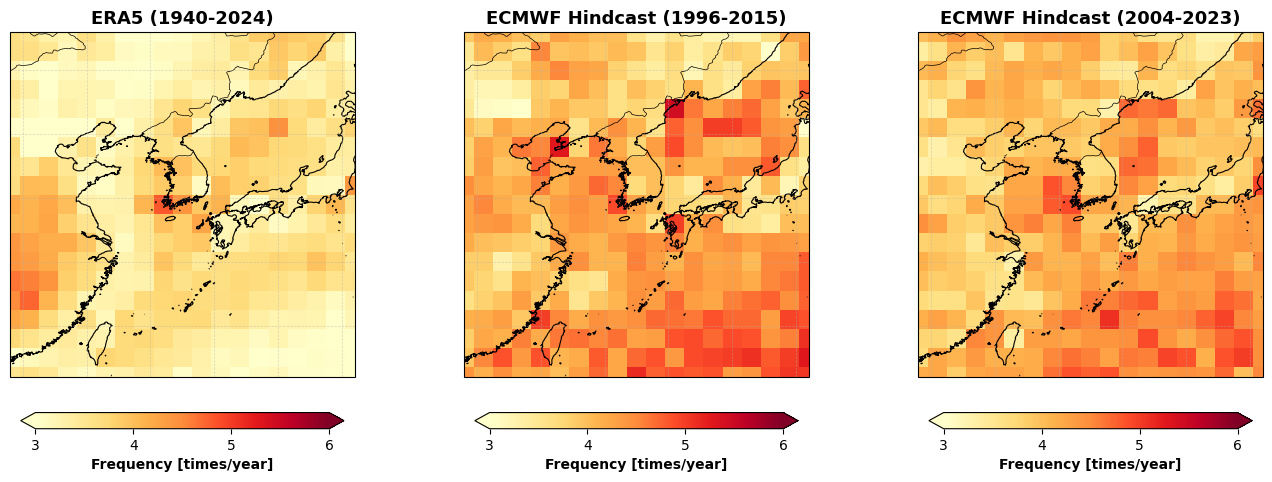

In [22]:
# Plotting
fig = plt.figure(figsize=(14, 5))
titles = ["ERA5 (1940-2024)", "ECMWF Hindcast (1996-2015)", "ECMWF Hindcast (2004-2023)"]  # Mean Annual Frequency
datasets = [era_freq, v16_freq, v24_freq]

for i, data in enumerate(datasets):
    ax = plt.subplot(1, 3, i+1, projection=ccrs.PlateCarree())
    ax.set_extent([114, 141, 21, 48], ccrs.PlateCarree())
    ax.coastlines("10m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    gl = ax.gridlines(draw_labels=False, linewidth=0.5, linestyle="--", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    # set vmin, vmax
    pcm = data.plot(
        ax=ax,
        cmap="YlOrRd",
        vmin=3,
        vmax=6,
        extend="both",
        transform=ccrs.PlateCarree(),
        add_colorbar=False
    )

    # colorbar
    cbar = plt.colorbar(pcm, ax=ax, orientation="horizontal", extend="both", shrink=0.70, pad=0.08)
    cbar.set_label("Frequency [times/year]", fontsize=10, fontweight="bold")

    # set ticks
    cbar.set_ticks([3, 4, 5, 6])

    ax.set_title(titles[i], fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(Output_Figures, "era5_v16_v24_t2m_Mean_Annual_Frequency90.png"), dpi=300, bbox_inches="tight")
plt.show()

----------------------------------------------------------------------------



---



> Comparison of **the Week 3 time series of abnormal high temperatures (AHT) in 2023** from ECMWF S2S (ver. 2024) against the ERA5 threshold climatology (1991–2020) at the target location (Seoul).

Setting **the coordinates of the Seoul** point to view the time series change of of the 2023 ECMWF abnormal high temperatures (AHT) relative to the ERA5 at the Seoul.

In [23]:
# Target point
target_lat = 37.57142
target_lon = 126.96582

*   Load ERA5 daily data

In [52]:
# Input ERA5 file
era5 = xr.open_dataset(os.path.join(Data_ERA5, "ERA5_7day_rolling_T2m_1940_2024.nc"))

# Input threshold: ERA5's threshold: 90 percentile of T2M (base: 1991-2020)
thr = xr.open_dataset(os.path.join(Data_ERA5, "T2m_thresholds_dataset.nc"))

- Load the other data

In [53]:
# Input ECMWF ver.2024
ds24 = xr.open_dataset(os.path.join(Data_ECMWF, "v2024_ECMWF_hindcast_T2M_w3_2004-2023.nc"))

# Input threshold: ECMWF's threshold: 90 percentile of T2M (ver.2024: 2004-2023)
thr24 = xr.open_dataset(os.path.join(Data_ECMWF, "v2024_ECMWF_hindcast_T2M_w3_clim90th.nc"))

In [54]:
print(era5)
print()
print(ds24)
print()
print(thr)
print()
print(thr24)

<xarray.Dataset> Size: 90MB
Dimensions:   (time: 31041, lat: 19, lon: 19)
Coordinates:
  * time      (time) datetime64[ns] 248kB 1940-01-01 1940-01-02 ... 2024-12-25
  * lat       (lat) float64 152B 48.0 46.5 45.0 43.5 ... 25.5 24.0 22.5 21.0
  * lon       (lon) float64 152B 114.0 115.5 117.0 118.5 ... 138.0 139.5 141.0
    doy       (time) int64 248kB ...
Data variables:
    t2m_7day  (time, lat, lon) float64 90MB ...

<xarray.Dataset> Size: 148MB
Dimensions:    (time: 7140, latitude: 72, longitude: 72)
Coordinates:
  * time       (time) datetime64[ns] 57kB 2004-01-19 2004-01-20 ... 2024-01-15
  * latitude   (latitude) float64 576B 57.0 55.5 54.0 52.5 ... -46.5 -48.0 -49.5
  * longitude  (longitude) float64 576B 52.5 54.0 55.5 ... 156.0 157.5 159.0
Data variables:
    t2m        (time, latitude, longitude) float32 148MB ...

<xarray.Dataset> Size: 255MB
Dimensions:    (doy: 366, lat: 121, lon: 240)
Coordinates:
  * doy        (doy) int64 3kB 1 2 3 4 5 6 7 8 ... 360 361 362 363 364 365

In [55]:
# Select nearest grid
ec = ds24.sel(latitude=target_lat, longitude=target_lon, method="nearest")
thr24 = thr24.sel(latitude=target_lat, longitude=target_lon, method="nearest")

er = era5.sel(lat=target_lat, lon=target_lon, method="nearest")
thr = thr.sel(lat=target_lat, lon=target_lon, method="nearest")

In [56]:
print(ec['t2m'][:5].values)

[268.75552 269.8197  268.51157 266.18057 265.56418]


In [57]:
print(er['t2m_7day'][:5].values)

[-4.4110648  -5.44778181 -7.26111886 -8.24323556 -8.58987601]


In [58]:
print(thr['clim_90th'][:5].values)

[273.86090262 273.88648333 273.86090262 273.88648333 273.69202706]


In [59]:
print(thr24['t2m_clim90th'][:5].values)

[271.23842773 272.80385742 273.37042236 273.01137695 272.60808105]


- Need to convert Kelvin to Celsius

In [61]:
# Kelvin -> Celsius
ec_t2m = ec["t2m"] - 273.15
ec_thr90 = thr24["t2m_clim90th"] - 273.15

er_t2m = er
thr90 = thr["clim_90th"] - 273.15

- Necessary to check if there are duplicate dates in the ECMWF data

In [62]:
# Remove duplicated dates (ECMWF only)
time_index = pd.Index(ec_t2m.time.values)
duplicate = time_index.duplicated()
ec_t2m = ec_t2m.isel(time=~duplicate)
print("Duplicated dates removed:", duplicate.sum())

Duplicated dates removed: 80


- In order to compare the time series change of AHT in 2023 with **the Normal year**
- Calculate the average value

In [63]:
# ECMWF: Mean values for the period 2004-2023
print("Calculating ECMWF Mean Values ...")
ec_mean = (ec_t2m.sel(time=slice("2004-01-01", "2023-12-31")).groupby("time.dayofyear").mean("time"))
ec_mean = ec_mean.rename({"dayofyear": "doy"})
#print(ec_clim)

Calculating ECMWF Mean Values ...


> **Although the ECMWF hindcast uses** a climatology period of **2004–2023**, the ERA5 climatology could not be matched to this period **because the ERA5 threshold climatology is defined over the 1991–2020** reference period. Therefore, **the ERA5 climatology period used in this exercise is 1991–2020**.

In [64]:
# ERA5: Mean values for the period 1991-2020
print("Calculating ERA5 Mean Values ...")
er_mean = (er_t2m.sel(time=slice("1991-01-01", "2020-12-31")).groupby("time.dayofyear").mean("time"))
er_mean = er_mean.rename({"dayofyear": "doy"})
#print(er_clim)

Calculating ERA5 Mean Values ...


In [65]:
# set 2023 data
ec2023 = ec_t2m.sel(time=slice("2023-01-01", "2023-12-31"))
er2023 = er_t2m.sel(time=slice("2023-01-01", "2023-12-31"))

In [66]:
# Convert to DataFrame to plot
df_ec2023 = pd.DataFrame({"time": ec2023.time.values, "doy": ec2023.time.dt.dayofyear.values, "ecmwf": ec2023.values})
df_er2023 = pd.DataFrame({"time": er2023.time.values, "doy": er2023.time.dt.dayofyear.values, "era5": er2023['t2m_7day'].values})

df_ec_clim = pd.DataFrame({"doy": ec_mean.doy.values, "ecmwf_mean": ec_mean.values})
df_er_clim = pd.DataFrame({"doy": er_mean.doy.values, "era5_mean": er_mean['t2m_7day'].values})

df_ec_thr = pd.DataFrame({"doy": ec_thr90.doy.values, "ec_thr90": ec_thr90.values})
df_thr = pd.DataFrame({"doy": thr90.doy.values, "thr90": thr90.values})

In [67]:
# Remove leap day
df_ec2023 = df_ec2023[df_ec2023.doy != 366]
df_er2023 = df_er2023[df_er2023.doy != 366]
df_ec_clim = df_ec_clim[df_ec_clim.doy != 366]
df_er_clim = df_er_clim[df_er_clim.doy != 366]

df_ec_thr = df_ec_thr[df_ec_thr.doy != 366]
df_thr = df_thr[df_thr.doy != 366]

In [68]:
# Merge by DOY
df = (df_er2023
      .merge(df_ec2023[["doy", "ecmwf"]], on="doy", how="inner")
      .merge(df_er_clim, on="doy", how="inner")
      .merge(df_ec_clim, on="doy", how="inner")
      .merge(df_ec_thr, on="doy", how="inner")
      .merge(df_thr, on="doy", how="inner"))

In [69]:
# sort by doy & check
df = df.sort_values("doy").reset_index(drop=True)
print(df.head())
print(df.tail())

        time  doy      era5     ecmwf  era5_mean  ecmwf_mean  ec_thr90  \
0 2023-01-01    1 -2.133477 -6.252899  -2.900426   -4.626678 -1.911572   
1 2023-01-03    3 -0.977100 -9.224396  -3.135426   -4.622080 -0.346143   
2 2023-01-04    4 -0.263722 -8.989960  -3.198440   -4.609597  0.220422   
3 2023-01-05    5  0.382353 -8.607117  -3.216798   -4.300277 -0.138623   
4 2023-01-06    6  1.224468 -8.076874  -3.268822   -4.337934 -0.541919   

      thr90  
0  0.710903  
1  0.710903  
2  0.736483  
3  0.542027  
4  0.456725  
          time  doy      era5     ecmwf  era5_mean  ecmwf_mean  ec_thr90  \
348 2023-12-27  361  1.193964 -0.654114  -2.782521   -3.534845  0.284607   
349 2023-12-28  362  1.163634 -0.855774  -2.705961   -2.867763  0.183920   
350 2023-12-29  363  1.351395 -0.846954  -2.781416   -3.072064 -0.294849   
351 2023-12-30  364  1.675492  0.223511  -2.892633   -3.315155 -0.631305   
352 2023-12-31  365  1.652843 -0.269531  -2.945272   -4.000357 -0.330292   

        thr90 

In [70]:
# Shading masks
mask_era5 = df["era5"] > df["thr90"]
mask_ecmwf = df["ecmwf"] > df["ec_thr90"]

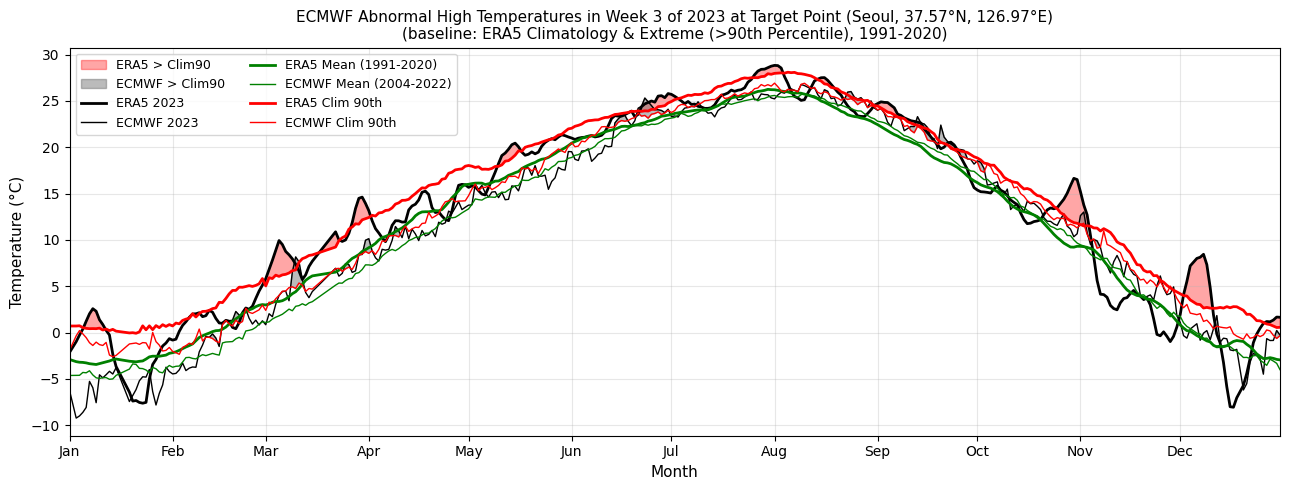

In [71]:
# Plot
plt.figure(figsize=(13, 5)) # 18, 7

# Shading:
plt.fill_between(df["doy"], df["thr90"], df["era5"], where=mask_era5, interpolate=True, color="red", alpha=0.35, label="ERA5 > Clim90")
plt.fill_between(df["doy"], df["ec_thr90"], df["ecmwf"], where=mask_ecmwf, interpolate=True, color="dimgray", alpha=0.45, label="ECMWF > Clim90")

# Lines
plt.plot(df["doy"], df["era5"], color="black", linewidth=2, linestyle="-", label="ERA5 2023")
plt.plot(df["doy"], df["ecmwf"], color="black", linewidth=1, linestyle="-", label="ECMWF 2023")
plt.plot(df["doy"], df["era5_mean"], color="green", linewidth=2, linestyle="-", label="ERA5 Mean (1991-2020)")
plt.plot(df["doy"], df["ecmwf_mean"], color="green", linewidth=1, linestyle="-", label="ECMWF Mean (2004-2022)")
plt.plot(df["doy"], df["thr90"], color="red", linewidth=2, linestyle="-",label="ERA5 Clim 90th")
plt.plot(df["doy"], df["ec_thr90"], color="red", linewidth=1, linestyle="-",label="ECMWF Clim 90th")

# Axis
month_ticks = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ["Jan", "Feb", "Mar", "Apr","May", "Jun", "Jul", "Aug","Sep", "Oct", "Nov", "Dec"]

plt.xticks(month_ticks, month_labels)
plt.xlim(1, 365)
plt.ylabel("Temperature (°C)", fontsize=11)
plt.xlabel("Month", fontsize=11)
plt.title("ECMWF Abnormal High Temperatures in Week 3 of 2023 at Target Point (Seoul, 37.57°N, 126.97°E)\n" + "(baseline: ERA5 Climatology & Extreme (>90th Percentile), 1991-2020)", fontsize=11)

plt.grid(alpha=0.3)
plt.legend(loc="upper left", fontsize=9, ncol=2)
plt.tight_layout()

# Save
plt.savefig(os.path.join(Output_Figures, "v2024_t2m_Extreme_y2023_Timeseries.png"), dpi=300, bbox_inches="tight")
plt.show()